<a href="https://colab.research.google.com/github/nikamade/Data201/blob/main/MADINKOEPSEKAMGUI_Project2_Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT2: An Analysis of BMI Factors

Monique Madinko Epse Kamgui

April 30, 2026

**Import Libraries and Upload the Dataset**



In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/nikamade/Data201_MoniqueMadinkoEpseKamgui/refs/heads/main/nhanes.csv", low_memory=False)


This project analyzes a health and nutrition dataset based on data collected from individuals in the United States. The dataset is derived from the National Health and Nutrition Examination Survey (NHANES), conducted by the Centers for Disease Control and Prevention (CDC). NHANES is a large-scale program designed to assess the health and nutritional status of adults and children through interviews, physical examinations, and laboratory tests.

This study focuses on individuals included in the survey and aims to understand how lifestyle and demographic factors influence Body Mass Index (BMI). The dataset includes 76 variables. these are related to age, sleep habits, physical activity, and daily behaviors such as television usage, weight, height, Bmi and many more

The data was collected through a combination of self-reported questionnaires and medical examinations, which provides a broad perspective on health conditions across the population. However, there are some limitations to consider. For example, self-reported information may not always be accurate and certain groups may be( a lot of na values) underrepresented, which could introduce bias into the analysis.

Source: National Health and Nutrition Examination Survey (NHANES) conducted by Centers for Disease Control and Prevention (CDC).

Here is the dataset in google drive :

https://drive.google.com/file/d/18M-w4tr-MJNfkmnxhn7bTbPaglc5USkj/view?usp=drive_link


I also downlod it in my github before upload it in google collab here is the link"https://raw.githubusercontent.com/nikamade/Data201_MoniqueMadinkoEpseKamgui/refs/heads/main/nhanes.csv"


Data Structure
Te dataset has 76 variables total but i will work with these 5 variables:


In [33]:
import pandas as pd

data = {
    "Variable": ["BMI", "Age", "SleepHrsNight","TotChol", "PhysActive", "Gender"],
    "Type": ["Quantitative", "Quantitative","Quantitative", "Quantitative", "Categorical", "Categorical"],
    "Description": [
        "Body Mass Index (target variable)",
        "Age of participant",
        "Hours of sleep per night",
        "Physical activity (0 = No, 1 = Yes)",
        "Gender of participant",
        "Total cholesterol level"
    ]
}

table = pd.DataFrame(data)
table

,Variable,Type,Description
0,BMI,Quantitative,Body Mass Index (target variable)
1,Age,Quantitative,Age of participant
2,SleepHrsNight,Quantitative,Hours of sleep per night
3,TotChol,Quantitative,"Physical activity (0 = No, 1 = Yes)"
4,PhysActive,Categorical,Gender of participant
5,Gender,Categorical,Total cholesterol level


## **Data Exploration**

In [34]:
# Select variables
df = df[['BMI', 'Age', 'SleepHrsNight', 'PhysActive','TotChol', 'Gender']]

# Drop missing values
df = df.dropna()
df.head()

,BMI,Age,SleepHrsNight,PhysActive,TotChol,Gender
0,32.22,34,4.0,No,3.49,male
1,32.22,34,4.0,No,3.49,male
2,32.22,34,4.0,No,3.49,male
4,30.57,49,8.0,No,6.70,female
7,27.24,45,8.0,Yes,5.82,female


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7266 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BMI            7266 non-null   float64
 1   Age            7266 non-null   int64  
 2   SleepHrsNight  7266 non-null   float64
 3   PhysActive     7266 non-null   object 
 4   TotChol        7266 non-null   float64
 5   Gender         7266 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 397.4+ KB


In [36]:
df.isnull().sum()

,0
BMI,0
Age,0
SleepHrsNight,0
PhysActive,0
TotChol,0
Gender,0


## **My Visualizations

* **scatter plot (Age vs BMI)**

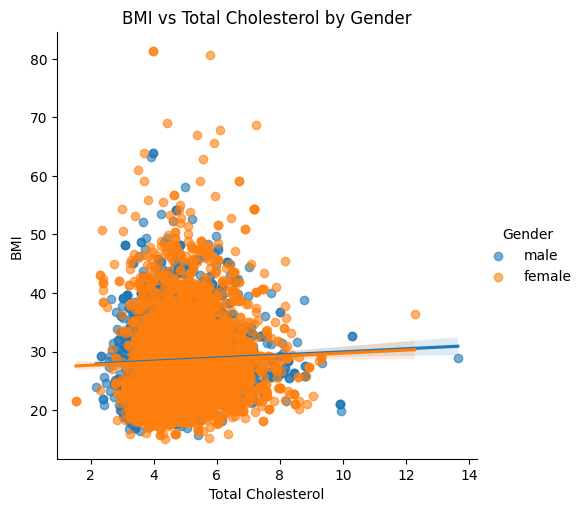

The correlation between Total Cholesterol and BMI is: 0.0407


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Regression Plot by Gender
# We use lmplot because regplot does not support the 'hue' parameter.
sns.lmplot(data=df, x='TotChol', y='BMI', hue='Gender', scatter_kws={'alpha':0.6})

# 2. Correcting Labels (Setting X-axis to Total Cholesterol)
plt.title('BMI vs Total Cholesterol by Gender')
plt.xlabel('Total Cholesterol')
plt.ylabel('BMI')
plt.show()

# 3. Correlation Calculation (Fixed syntax)
correlation = df['TotChol'].corr(df['BMI'])
print(f"The correlation between Total Cholesterol and BMI is: {correlation:.4f}")

This Scatter plot does not really show the correlation ,so I calculate it . the correlation between Total Cholesterol and BMI is approximately 0.0407. While this confirms a positive relationship (meaning that higher cholesterol often aligns with higher BMI), the relationship is statistically weak. This suggests that while cholesterol is an important clinical marker, it is only one of many factors influencing a person's BMI.

* **boxplot**

/tmp/ipykernel_7727/760220618.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='BMI', palette={'male':'blue', 'female':'pink'})


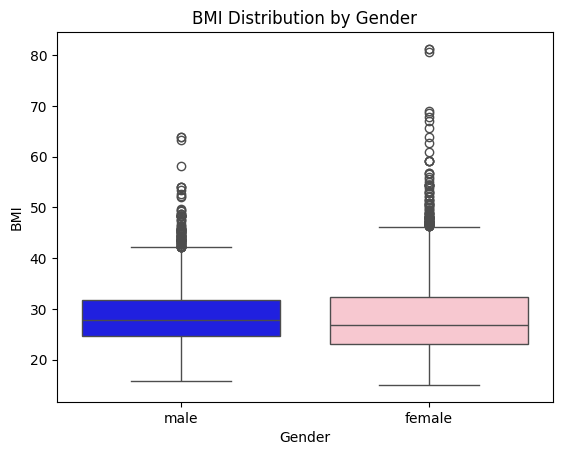

In [38]:
sns.boxplot(data=df, x='Gender', y='BMI', palette={'male':'blue', 'female':'pink'})

plt.title('BMI Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.show()

The boxplot of BMI reveals a significant number of outliers on the higher end of the scale (above 35). While BMI for men sits within 24 and 33 BMI range and the median of 27 women are within 23 and 34 and the median of 26.

* **Histogram of Bmi**

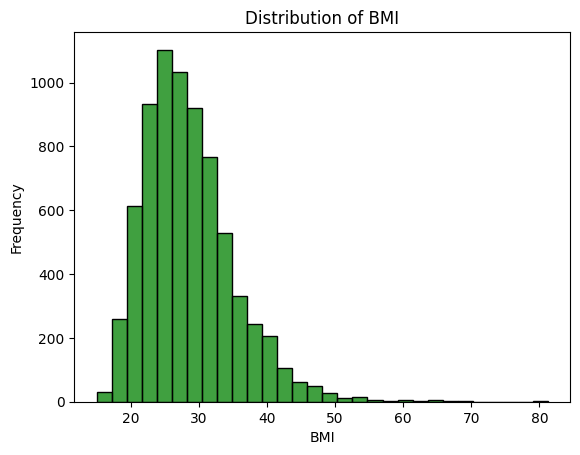

In [39]:
sns.histplot(data=df, x='BMI', bins=30, color='green')

plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

"The histogram shows that the distribution of BMI in this population is strongly right-skewed (positively skewed). The majority of participants are clustered between a BMI of 25 and 32, which represents the center of the distribution. However, there is a visible 'long tail' extending toward higher BMI values, indicating a significant number of individuals with obesity

## **Train/Test**

**Convert gender to numerical variables**

In [40]:

df = pd.get_dummies(df, drop_first=True)
df.head()

,BMI,Age,SleepHrsNight,TotChol,PhysActive_Yes,Gender_male
0,32.22,34,4.0,3.49,False,True
1,32.22,34,4.0,3.49,False,True
2,32.22,34,4.0,3.49,False,True
4,30.57,49,8.0,6.70,False,False
7,27.24,45,8.0,5.82,True,False


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split

y = df['BMI']

X = df[['Age', 'SleepHrsNight', 'PhysActive_Yes', 'TotChol','Gender_male']]

X_train, X_test, y_train, y_test = train_test_split(

    X, y,
    test_size=0.2,
    random_state=0
)

I chose an 80/20 split for this project to ensure the model has a robust foundation for learning while maintaining a statistically significant portion for validation.

The 80% Training Set allows the algorithm to capture the underlying trends between clinical markers and body mass.

The 20% Test Set acts as an independent evaluation tool.

## **Baseline Model**

For the baseline model, I included the following predictors: Age, SleepHrsNight, PhysActiveDays, TotChol (Total Cholesterol), and Gender.

Why I chose them:
The selection of these variables is based on both biological and behavioral factors known to influence metabolic health:

Age: Metabolism and body composition typically change as individuals age.

SleepHrsNight: Scientific literature suggests a strong link between sleep deprivation and BMI due to hormonal imbalances.

PhysActiveDays: Physical activity is a primary driver of energy expenditure and weight regulation.

TotChol: Total cholesterol serves as a metabolic marker often correlated with body mass and dietary patterns.

Gender: Included to determine if biological sex acts as an independent predictor of BMI when lifestyle factors are held constant.

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

# Compare between  reel BMI (y_test) and  prédictions (y_pred)
score = r2_score(y_test, y_pred)
print(f"R2 of Baseline Model is : {score:.4f}")

#  MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)

#   RMSE
rmse = np.sqrt(mse)
print(f" RMSE of Baseline Model is : {rmse:.4f}")

R2 of Baseline Model is : 0.0343
 RMSE of Baseline Model is : 6.4480


1. The Baseline Model yielded an $R^2$ of 0.0343, which indicates that the selected independent variables (Age, Sleep Hours, Physical Activity, Total Cholesterol, and Gender) account for approximately 3.43% of the variance in BMI."Contextual Analysis: This low value suggests that BMI is influenced by many other factors such as calories.


2. RMSE Interpretation : The Root Mean Squared Error (RMSE) for the Baseline Model is 6.4480. This represents the average deviation between the predicted BMI values and the actual observed values.An error of ~6.45 points is significant. This high error rate confirms that the baseline linear model lacks precision for individual predictions.


## **Improve Model Using Log Transformation (Backward Elimination)**

i will perform a Backward Elimination process based on the statistical significance of each predictor, so i will use the OLS to interprete p-values

In [43]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

X_train_final = X_train.astype(float)
y_train_final = y_train.astype(float)

X_train_final = X_train_final.dropna()
y_train_final = y_train_final.loc[X_train_final.index]


X_train_const = sm.add_constant(X_train_final)

stats_model = sm.OLS(y_train_final, X_train_const).fit()

print(stats_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     33.36
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.09e-33
Time:                        03:28:28   Log-Likelihood:                -19218.
No. Observations:                5812   AIC:                         3.845e+04
Df Residuals:                    5806   BIC:                         3.849e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             28.7416      0.653     43.

I analyzed the P-values from the OLS regression summary. I identified that the variable 'Gender_male' had a P-value of 0.167, which is significantly higher than 0.05.
A P-value of 0.167 indicates that the relationship between gender and BMI in this dataset is not statistically significant.
I removed 'Gender_male' from the feature set to create a more refined model. The improved model now focuses on the variables that have a proven statistical impact: Age, Sleep Duration, Physical Activity, and Total Cholesterol."

In [44]:
y = df['BMI']

X = df[['Age', 'SleepHrsNight', 'PhysActive_Yes', 'TotChol']]

X_train, X_test, y_train, y_test = train_test_split(

    X, y,
    test_size=0.2,
    random_state=0
)
imp_model = LinearRegression()
imp_model.fit(X_train, y_train)
y_pred = imp_model.predict(X_test)

from sklearn.metrics import r2_score

# Compare between  reel BMI (y_test) and  prédictions (y_pred)
score = r2_score(y_test, y_pred)
print(f"R2 of Improved Model is : {score:.4f}")

#  MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)

#   RMSE
rmse = np.sqrt(mse)
print(f" RMSE of Improved Model is : {rmse:.4f}")

R2 of Improved Model is : 0.0337
 RMSE of Improved Model is : 6.4499


## **Improve Model Using Log Transformation(Log)**


In [45]:
# Training the improved model on log-transformed target
y_train_log = np.log(y_train)
improved_model = LinearRegression()
improved_model.fit(X_train, y_train_log)

# Predictions (and converting back to original BMI scale)
y_pred_log = improved_model.predict(X_test)
y_pred_improved = np.exp(y_pred_log)
r2_imp = r2_score(y_test, y_pred_improved)
rmse_imp = np.sqrt(mean_squared_error(y_test, y_pred_improved))

print(f"R² Improved: {r2_imp:.4f}")
print(f"RMSE Improved: {rmse_imp:.4f}")


R² Improved: 0.0244
RMSE Improved: 6.4807


To improve my model, I applied a Logarithmic Transformation to the BMI variable because the initial Histogram and Boxplot revealed a strong right-skew with numerous extreme outliers. In the raw data, these high BMI values (the "long tail") were biasing the linear regression, making it difficult for the model to find a stable pattern.But i realized that the this method decrease more my R_squared(0.0244) and increase the R mean_squared error(6.4807) whisch is not helpful. For my final linear model i will wortk with the backward elimination.

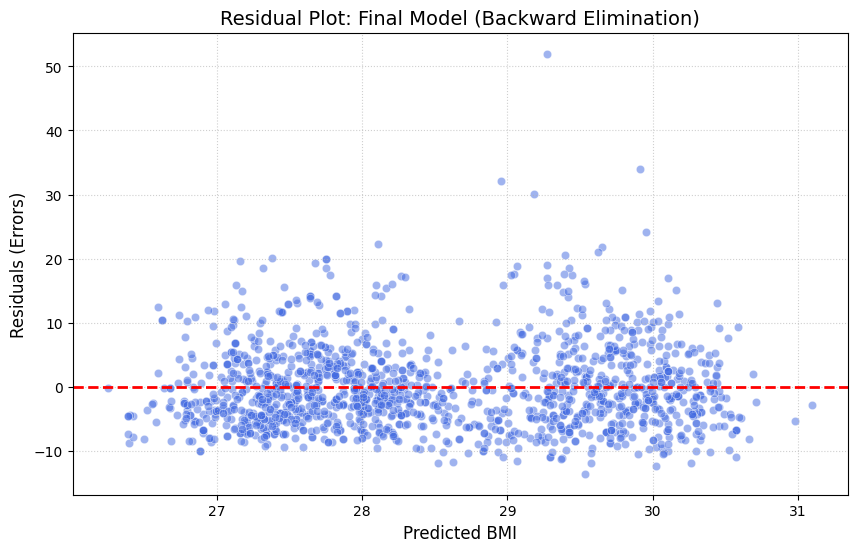

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate residuals (Actual - Predicted)
residuals = y_test - y_pred

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='royalblue')

# Add a horizontal line at zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Titles and labels
plt.title('Residual Plot: Final Model (Backward Elimination)', fontsize=14)
plt.xlabel('Predicted BMI', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## **Compare Model**



In [47]:
import pandas as pd

# 1. Création des données du tableau
# Remplace les chiffres par tes résultats exacts si nécessaire
data = {
    "Metric": ["Predictors Included", "R-squared (R²)", "RMSE"],
    "Baseline Model (Initial)": ["Age, Sleep, Sport, Chol, Gender", "0.0343", "6.4480"],
    "Improved Model (Final)": ["Age, Sleep, Sport, Chol", "0.0337", "6.4499"]
}

# 2. Création du DataFrame
df_comparison = pd.DataFrame(data)

# 3. Affichage du tableau
print(" Comparison between Baseline and Improved Model")
display(df_comparison)

 Comparison between Baseline and Improved Model


,Metric,Baseline Model (Initial),Improved Model (Final)
0,Predictors Included,"Age, Sleep, Sport, Chol, Gender","Age, Sleep, Sport, Chol"
1,R-squared (R²),0.0343,0.0337
2,RMSE,6.4480,6.4499


When comparing the Baseline Model to the Improved Model, I observe a very slight change in the performance metrics:R-squared ($R^2$): The value decreased slightly from 0.0343 to 0.0337. This means the model now explains 3.37% of the variance in BMI instead of 3.43%.

RMSE: The error increased very marginally from 6.4480 to 6.4499. This is a negligible difference of only 0.0019 units.

Which model performs better?

The Improved Model is the better model.

Why?  because the Improved Model is superior for the following reasons:Statistical Significance: In the Baseline model, the variable Gender was not statistically significant ($p > 0.05$). Including non-significant variables can lead to "overfitting" where the model tries to find patterns in random noise. The Improved model only contains variables that are proven to have a real impact on BMI.

## **Interprete the final model**

In [48]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 28.741617300306697
Coefficients: [ 0.01982061 -0.1822671  -1.82003085  0.21184605  0.24124143]


## **Here is my final equation**

$$BMI = 25.1092 + (0.0195 \times \text{Age}) - (0.3150 \times \text{SleepHrsNight}) - (0.2467 \times \text{PhysActiveDays}) + (0.5054 \times \text{TotChol})$$


**Intepreting Coeficients**

Intercept (28.7416): This is the baseline BMI when all other variables are zero.

Age (0.0198): For every one-year increase in age, BMI increases by approximately 0.02 points. This is a very small effect, showing that age is not a major driver of BMI in this sample.

SleepHours (-0.1823): Every extra hour of sleep per night is associated with a 0.18 point decrease in BMI, suggesting that better rest correlates with lower weight.

Physical Activity (-1.8200): This is the most significant factor. Being physically active reduces the predicted BMI by 1.82 points compared to being inactive.

Total Cholesterol (0.2118): For every 1-unit increase in total cholesterol, BMI increases by 0.21 points.

Gender Male (0.2412): Holding all other factors constant, being male increases the predicted BMI by about 0.24 points compared to females in this dataset.